In [49]:
import pandas as pd
import numpy as np
import pickle as pkl
from matplotlib import pyplot as plt
import seaborn as sns
import psychofit as pfit

In [107]:
df = pd.read_parquet(
    "../data/ephys_neurometric/NYU-11/6713a4a7-faed-4df2-acab-ee4e63326f8d/MG_decoding_summary.pqt"
)

In [51]:
low_mean = np.mean(np.vstack(df["low_slope"].values), axis=0)  # type: ignore
high_mean = np.mean(np.vstack(df["high_slope"].values), axis=0)  # type: ignore

In [65]:
trials_df = pd.read_parquet(
    "../data/ephys_neurometric/NYU-11/6713a4a7-faed-4df2-acab-ee4e63326f8d/trials.pqt"
)
y_true = np.load(
    "../data/ephys_neurometric/NYU-11/6713a4a7-faed-4df2-acab-ee4e63326f8d/targets_real.npy"
).squeeze()
y_pred = np.load(
    "../data/ephys_neurometric/NYU-11/6713a4a7-faed-4df2-acab-ee4e63326f8d/MG_predictions_real.npy"
).squeeze()

In [66]:
valid_trials = trials_df[trials_df["mask"] == True].copy()

In [67]:
valid_trials["decoder_pred"] = np.mean(y_pred, axis=0)

In [68]:
y_true_transform = np.tanh(5 * y_true) / np.tanh(5)

In [73]:
valid_trials["signcon"] = np.nan_to_num(valid_trials.contrastLeft) - np.nan_to_num(
    valid_trials.contrastRight
)

In [74]:
valid_trials["decoder_choice_left"] = (valid_trials["decoder_pred"] > 0).astype(int)

In [75]:
dots_df = (
    valid_trials.groupby(["blockprob_neurometric", "signcon"])["decoder_choice_left"]
    .mean()
    .reset_index()
)

In [76]:
q1_dots = dots_df[dots_df["blockprob_neurometric"] == 0]
q4_dots = dots_df[dots_df["blockprob_neurometric"] == 1]

In [108]:
df

,eid,subject,probe,region,pseudo_id,run_id,N_units,R2_test,nb_trials,weights,intercept,low_slope,high_slope
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,-1,0,12,0.042340,443,"[0.008664471969943577, -0.002075864946639783, ...",0.051404,0.009705,0.022931
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,-1,1,12,0.079160,443,"[0.008041040705145974, -0.0010280018074471542,...",0.055810,0.013768,0.127881
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,1,0,12,-0.037393,443,"[-0.04898220546740752, -0.001744959621975184, ...",0.381223,1.568539,2.244309
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,1,1,12,-0.022890,443,"[-0.04938695775868993, -0.002039912550555556, ...",0.382933,1.294543,2.630916
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,2,0,12,-0.041074,443,"[-0.011969049454002345, -0.020326549601249154,...",0.078572,9.905614,0.683379
5,6713a4a7-faed-4df2-acab-ee4e63326f8d,NYU-11,probe00,MG,2,1,12,-0.035585,443,"[-0.011659441206347765, -0.01996676198460392, ...",0.075127,1.717725,-0.857612


In [105]:
df = pd.read_parquet(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/LGd_decoding_summary.pqt"
)

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psychofit as pfit

df = pd.read_parquet(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/LGd_decoding_summary.pqt"
)
trials_df = pd.read_parquet(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/trials.pqt"
)
y_pred = np.load(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/LGd_predictions_real.npy"
).squeeze()

empirical_data = df[df["pseudo_id"] == -1]
y_pred_mean = np.mean(y_pred, axis=0)


plot_groups = {
    0: {"label": "Low engagement", "color": "blue", "pars_col": "low_pars"},
    1: {"label": "High engagement", "color": "red", "pars_col": "high_pars"},
}

valid_trials = trials_df[trials_df["mask"] == True].copy()
valid_trials["decoder_pred"] = y_pred_mean
valid_trials["decoder_choice_left"] = (valid_trials["decoder_pred"] > 0).astype(int)
valid_trials["signcon"] = np.nan_to_num(valid_trials.contrastLeft) - np.nan_to_num(
    valid_trials.contrastRight
)

dots_df = (
    valid_trials.groupby(["blockprob_neurometric", "signcon"])["decoder_choice_left"]
    .mean()
    .reset_index()
)

In [106]:
df

,eid,subject,probe,region,pseudo_id,run_id,N_units,R2_test,nb_trials,weights,...,q1_pars,q4_pars,q2_pars,q3_pars,q1_slope,q2_slope,q3_slope,q4_slope,low_slope,high_slope
0,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,-1,0,30,0.098814,462,"[0.04831060990154175, 0.04570813922198993, 0.0...",...,"[-0.8002147957689763, 1.0590149113012375, 2.81...","[-0.2908925944139383, 0.15358818709854186, 0.1...","[-0.15313073443987182, 0.3025150869473744, 0.1...","[-0.25437131830930515, 0.02764068720212, 9.033...",1.059015,0.302515,0.027641,0.153588,1.059015,0.153588
1,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,-1,1,30,0.078595,462,"[0.04884356265716807, 0.045564250257585745, 0....",...,"[-0.06433931704614072, 0.18653399231930973, 0....","[-0.8456325885429022, 0.9217556829577459, 2.41...","[-0.26630097613293824, 0.31507370832643444, 0....","[-0.2305674964367873, 0.24489369210174214, 1.2...",0.186534,0.315074,0.244894,0.921756,0.186534,0.921756
2,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,1,0,30,-0.048661,462,"[0.1022032752570345, -0.04674800509967767, 0.0...",...,"[-0.16824796354118865, 0.19874294334932008, 0....","[-0.10410149164544191, 0.5099761243614847, 0.3...","[0.0011501664130704548, 0.0021992346359979093,...","[-0.10634729944483068, 0.1529385528808707, 0.3...",0.198743,0.002199,0.152939,0.509976,0.198743,0.509976
3,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,1,1,30,-0.112013,462,"[0.10638708460912909, -0.05155034269093069, 0....",...,"[0.9981738126811251, -1.6406416046113148, 0.23...","[-0.9999999953965814, 9.342198614214194, 0.399...","[0.9991163769283521, 6.120700698493591, 0.3999...","[0.9933533278601341, 2.4506055588053695, 0.399...",-1.640642,6.120701,2.450606,9.342199,-1.640642,9.342199


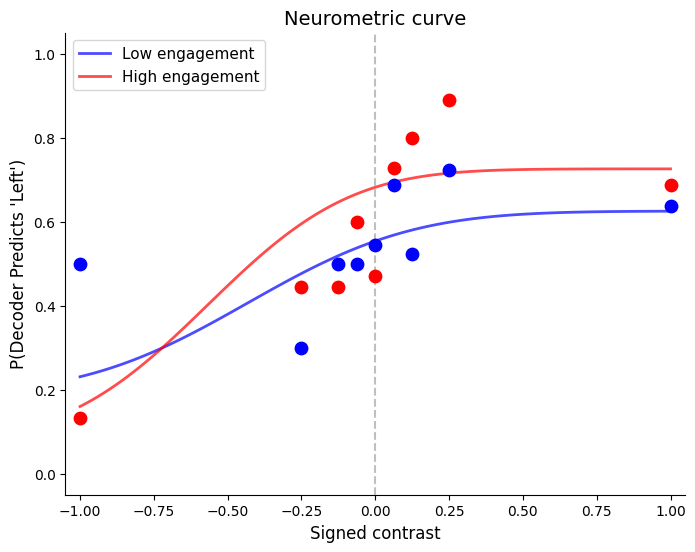

In [91]:
plt.figure(figsize=(8, 6))
smooth_x = np.linspace(-1, 1, 100)

for split_idx, config in plot_groups.items():

    dots = dots_df[dots_df["blockprob_neurometric"] == split_idx]
    plt.scatter(
        dots["signcon"], dots["decoder_choice_left"], color=config["color"], s=80, zorder=5
    )

    raw_pars = np.vstack(empirical_data[config["pars_col"]].values)
    mean_pars = np.nanmean(raw_pars, axis=0).squeeze()

    smooth_y = pfit.erf_psycho_2gammas(mean_pars, smooth_x)
    plt.plot(
        smooth_x, smooth_y, color=config["color"], linewidth=2, alpha=0.7, label=config["label"]
    )
plt.axvline(0, color="gray", linestyle="--", alpha=0.5)

plt.title(
    "Neurometric curve",
    fontsize=14,
)
plt.xlabel("Signed contrast", fontsize=12)
plt.ylabel("P(Decoder Predicts 'Left')", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.xlim([-1.05, 1.05])
plt.ylim([-0.05, 1.05])
sns.despine()

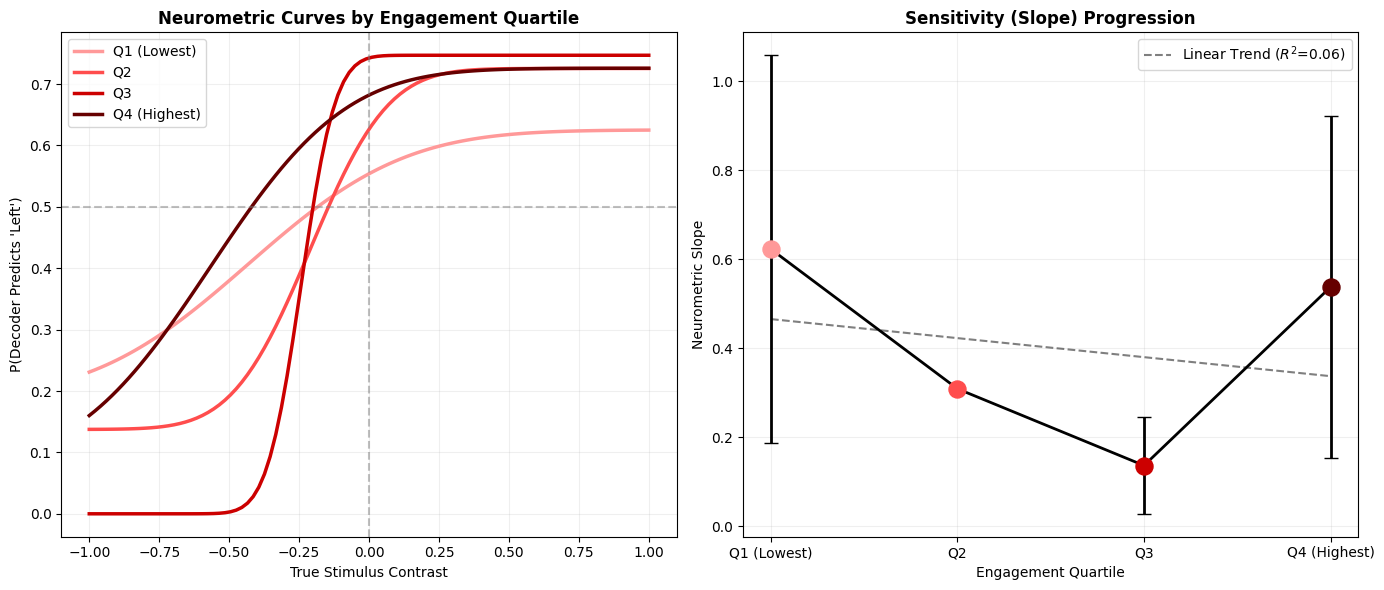

In [19]:
from scipy import stats


df = pd.read_parquet(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/LGd_decoding_summary.pqt"
)
trials_df = pd.read_parquet(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/trials.pqt"
)
y_pred = np.load(
    "../data/ephys_neurometric/CSHL045/034e726f-b35f-41e0-8d6c-a22cc32391fb/LGd_predictions_real.npy"
).squeeze()

empirical = df[df["pseudo_id"] == -1]
slope_cols = ["q1_slope", "q2_slope", "q3_slope", "q4_slope"]
mean_slopes = [empirical[col].mean() for col in slope_cols]
sem_slopes = [empirical[col].sem() for col in slope_cols]
quartiles = [1, 2, 3, 4]

# Extract Mean Curve Parameters
q_pars = []
for col in ["q1_pars", "q2_pars", "q3_pars", "q4_pars"]:
    raw_pars = np.vstack(empirical[col].values)
    q_pars.append(np.nanmean(raw_pars, axis=0).squeeze())

# ==========================================
# 2. PLOT THE PROGRESSION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define a color gradient (Light Red -> Dark Red)
colors = ["#ff9999", "#ff4d4d", "#cc0000", "#660000"]
labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]

# --- PANEL A: The Gradient S-Curves ---
smooth_x = np.linspace(-1, 1, 100)
for i in range(4):
    smooth_y = pfit.erf_psycho_2gammas(q_pars[i], smooth_x)
    ax1.plot(smooth_x, smooth_y, color=colors[i], linewidth=2.5, label=labels[i])

ax1.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax1.set_title("Neurometric Curves by Engagement Quartile", fontweight="bold")
ax1.set_xlabel("True Stimulus Contrast")
ax1.set_ylabel("P(Decoder Predicts 'Left')")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.2)

# --- PANEL B: The Slope Trend ---
ax2.errorbar(
    quartiles,
    mean_slopes,
    yerr=sem_slopes,
    fmt="-o",
    color="black",
    linewidth=2,
    markersize=8,
    capsize=5,
    zorder=5,
)

# Color the dots to match the curves
for i in range(4):
    ax2.scatter(quartiles[i], mean_slopes[i], color=colors[i], s=150, zorder=10)

# Calculate a quick linear trendline
slope, intercept, r_value, p_value, std_err = stats.linregress(quartiles, mean_slopes)
ax2.plot(
    quartiles,
    intercept + slope * np.array(quartiles),
    "k--",
    alpha=0.5,
    label=f"Linear Trend ($R^2$={r_value**2:.2f})",
)

ax2.set_title("Sensitivity (Slope) Progression", fontweight="bold")
ax2.set_xlabel("Engagement Quartile")
ax2.set_ylabel("Neurometric Slope")
ax2.set_xticks(quartiles)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [18]:
df

,eid,subject,probe,region,pseudo_id,run_id,N_units,R2_test,nb_trials,weights,intercept,low_pars,high_pars,q1_pars,q4_pars,q2_pars,q3_pars
0,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,-1,0,30,0.096365,462,"[0.046072202835538346, 0.04794151039497798, 0....",0.072777,"[-0.12628601202138467, 0.012046787408713462, 0...","[-0.5671850944152408, 0.058663469060998966, 0....","[-0.12628601202138467, 0.012046787408713462, 0...","[-0.5671850944152408, 0.058663469060998966, 0....","[-0.44933019821681486, 0.4773715154929056, 0.1...","[-0.2790047633385047, 0.04445130880196075, 6.9..."
1,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,-1,1,30,0.033363,462,"[0.04807936534095596, 0.04220438484064486, 0.0...",0.068565,"[0.06520094148011743, 0.2148630159705298, 0.39...","[-0.6877202565917669, 0.7930658404544171, 0.01...","[0.06520094148011743, 0.2148630159705298, 0.39...","[-0.6877202565917669, 0.7930658404544171, 0.01...","[-0.14180787132629508, 0.19486208713030218, 0....","[-0.2877879672032128, 0.1529687029203569, 7.95..."
2,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,1,0,30,-0.151128,462,"[-0.0451793569225913, 0.11280861106382148, 0.0...",0.011682,"[0.576429882686647, 0.784873356854727, 0.39999...","[0.6394707965560606, -1.9365849801890889, 7.27...","[0.576429882686647, 0.784873356854727, 0.39999...","[0.6394707965560606, -1.9365849801890889, 7.27...","[-0.017510706652744873, -0.20107247567646674, ...","[0.965316767628853, -1.2911978759936917, 0.189..."
3,034e726f-b35f-41e0-8d6c-a22cc32391fb,CSHL045,merged_probes,LGd,1,1,30,-0.188300,462,"[-0.04703814966703827, 0.11079759864191034, 0....",0.018006,"[-0.2268480439401755, -0.4938611000828226, 0.3...","[-0.11779729135661557, -0.37194165415114555, 0...","[-0.2268480439401755, -0.4938611000828226, 0.3...","[-0.11779729135661557, -0.37194165415114555, 0...","[-0.9999999899235602, 1.9774451780654956, 0.15...","[-0.011025872206579902, -0.4240535560847381, 0..."
